# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_1h.parquet")

In [4]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,1,residential,2,2,0.000000,1121.500000,6.430000,20.455000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01 00:00:00,482136,2,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01 00:00:00,482136,3,residential,7,7,15.000000,1244.142857,5.698571,19.598571,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01 00:00:00,482136,4,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01 00:00:00,482136,5,residential,2,2,0.000000,1338.500000,5.190000,17.780000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674515,2025-12-31 23:00:00,490895,73,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
674516,2025-12-31 23:00:00,490895,74,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
674517,2025-12-31 23:00:00,490895,75,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
674518,2025-12-31 23:00:00,490895,76,airport,20,20,162.692308,1574.900000,14.826000,37.737500,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    674,520
Unique combinations (no time) :    674,520
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  674,520 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :    1,848
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :  308,314  (45.7%)
Non-zero-demand rows           :  366,206  (54.3%)


In [6]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,2,2,0.0,1121.500000,6.430000,20.455000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,0,0,0.0,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,7,7,15.0,1244.142857,5.698571,19.598571,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,0,0,0.0,0.000000,0.000000,0.000000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,2,2,0.0,1338.500000,5.190000,17.780000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

# --- community-area embedding ---
CA_EMBED_DIM       = 16

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    CA_EMBED_DIM   = CA_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade

## 4.2.3 Model Definition

In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_ca, embed_dim):
        super().__init__()
        self.ca_embed = nn.Embedding(n_ca, embed_dim)
        nn.init.normal_(self.ca_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, ca_idx):
        emb = self.ca_embed(ca_idx)           # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)     # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    _embed_dim = embed_dim if embed_dim is not None else config.CA_EMBED_DIM
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_CA, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(ca_train, dtype=torch.long),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    ca_val_t = torch.as_tensor(ca_val, dtype=torch.long).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, cb, yb in train_dl:
            xb, cb, yb = xb.to(device), cb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, cb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, ca_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  ca_train, ca_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        ca_train, ca_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           ca_train, ca_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         ca_train, ca_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers used after every training run below: `evaluate_models` computes the test-set metrics for the per-seed models of one architecture and returns the result rows, `save_results` appends them to the results CSV.

In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, ca_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    ca_test_t  = torch.as_tensor(ca_test,  dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, ca_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check (MSE, log1p scale) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌──────────────────────┬──────────────────────────────┬─────────────┐
│ pickup_community_area│  is_weekend, temp, rain, ...  │ trip_count  │
│         8            │  0,  12.3,  0.0,  ...        │      5      │
└──────────┬───────────┴───────────────┬───────────────┴──────┬──────┘
           │                           │                       │
           ▼                           ▼                       ▼
       ca_vocab                  StandardScaler            target y
        8 → 7                   [0.0, -0.3, ...]              5.0
           │                           │
           ▼                           │
   Embedding table                     │
 (N_CA areas × 16 dims)                │
  row 7: [0.12, -0.31, ...]            │
    (16 dims, learned)                 │ (n_num dims, scaled)
           │                           │
           └──────────────┬────────────┘
                          ▼
                    torch.cat(...)
         [0.12, -0.31, ...,  0.0, -0.3, ...]
               (16 + n_num total dims)
                          │
                          ▼
              ┌─────────────────────┐
              │  Linear(dim → 64)   │
              │  ReLU               │
              │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
              │  ReLU               │
              │  Linear(64 → 1)     │
              │  Softplus           │  ← keeps output ≥ 0 (trip count)
              └─────────────────────┘
                          │
                          ▼
                   ŷ  (predicted trip count)
```

The embedding table starts with near-zero weights and is updated by backprop
alongside all other parameters — the network learns which areas are similar.

## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :   472,164 rows
Val   :   101,178 rows
Test  :   101,178 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Community Area Encoding

Community area identity is encoded with a **learnable embedding** (vocabulary
built on the training set only). Each of the `N_CA` areas maps to a
`CA_EMBED_DIM`-dimensional vector that is trained jointly with the network and
concatenated with the scaled numeric features before the first linear layer.

This replaces the previous one-hot encoding: instead of ~77 sparse binary
columns the model learns a dense representation in which similar areas end up
close together, matching the approach used in the hexagon notebooks. Areas
unseen in training fall back to a reserved "unknown" embedding row.

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]


Numeric features (22): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'apparent_temperature', 'precipitation', 'wind_speed_10m', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique community areas (train) : 77  |  embed dim : 16
Unseen areas  val: 0   test: 0

X_train : (472164, 22)   y_train : (472164,)
X_val   : (101178, 22)     y_val   : (101178,)
X_test  : (101178, 22)    y_test  : (101178,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

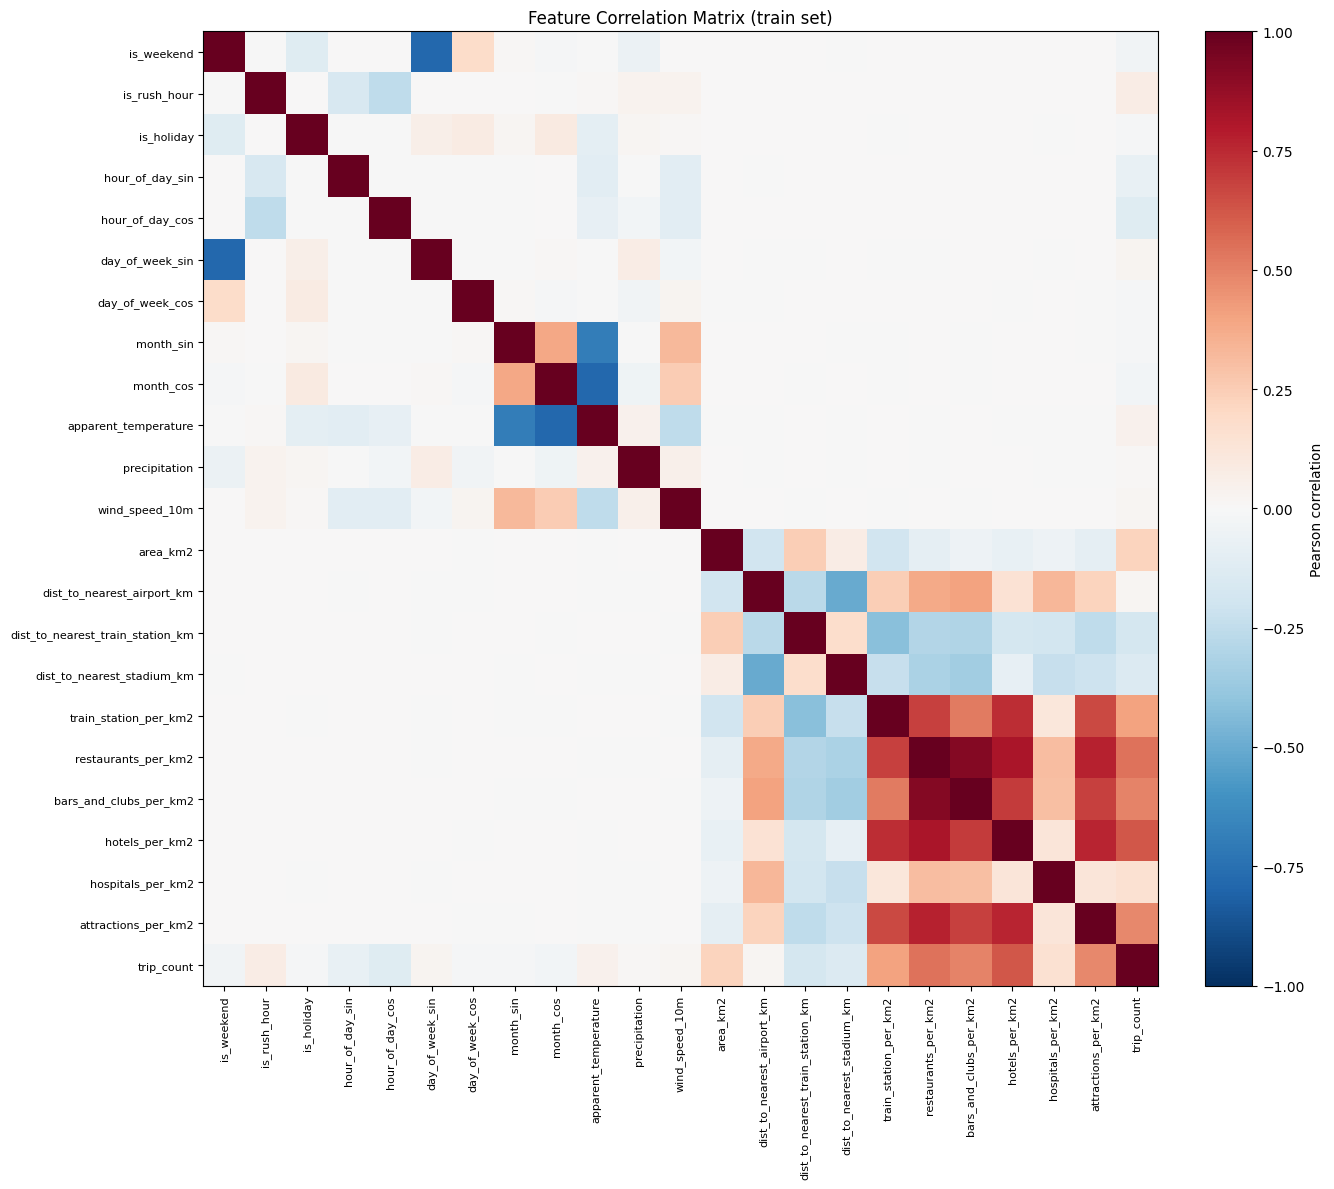

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820


In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.412026         1.212591             0.004813
                 hour_of_day_cos       0.161719         0.371911             0.002676
                 hour_of_day_sin       0.127756         0.277614             0.003575
      dist_to_nearest_airport_km       0.073904         0.111444             0.000675
                        area_km2       0.084288         0.109317             0.000741
                 day_of_week_sin       0.027957         0.048289             0.000894
      dist_to_nearest_stadium_km       0.021211         0.034086             0.000150
                      is_weekend       0.018415         0.023741             0.000525
                    is_rush_hour       0.006997         0.021910             0.000455
                       month_cos       0.011908         0.021310             0.000391
                 day_of_week_cos       0.006058       

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    "temperature_2m", "rain", "wind_speed_10m",
    "poi_density_total_per_km2",
    "universities_per_km2",
    # "cloud_cover",
    "is_day", 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover',
    # "snowfall"
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# community-area embedding indices — vocabulary built from the training set only;
# areas unseen in training map to a reserved "unknown" index
ca_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_community_area'].unique()))}
UNK_CA   = len(ca_vocab)
N_CA     = len(ca_vocab) + 1   # +1 for the unknown bucket

ca_train = train_data['pickup_community_area'].map(ca_vocab).astype(int).values
ca_val   = val_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values
ca_test  = test_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values

print(f"Unique community areas (train) : {len(ca_vocab)}  |  embed dim : {CA_EMBED_DIM}")
print(f"Unseen areas  val: {(ca_val == UNK_CA).sum()}   test: {(ca_test == UNK_CA).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296

Historical mean (area × hour)        R²=0.8174  MAE=3.4796  RMSE=13.9161  NRMSE=1.8482  MAPE=70.4%
Ridge regression                     R²=0.5521  MAE=7.3660  RMSE=21.7957  NRMSE=2.8947  MAPE=283.5%


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# input_dim = X_train.shape[1]
# n_layers, width = ARCH_BASELINE

# viz_model = DemandBaseline(input_dim, n_layers, width)
# x_dummy   = torch.zeros(1, input_dim)
# summary(viz_model, input_data=x_dummy, col_names=["input_size", "output_size", "num_params"], verbose=1)

In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu



/var/folders/2y/_wxqgfb555717vrjqjj3kyvm0000gn/T/ipykernel_76978/2630984982.py:98: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  torch.as_tensor(ca_train, dtype=torch.long),


Epoch   1/300
  loss: 2.6126  val_loss: 2.3325 ✓
Epoch   2/300
  loss: 2.2265  val_loss: 2.1468 ✓
Epoch   3/300
  loss: 2.1167  val_loss: 2.0640 ✓
Epoch   4/300
  loss: 2.0594  val_loss: 2.0183 ✓
Epoch   5/300
  loss: 2.0247  val_loss: 1.9904 ✓
Epoch   6/300
  loss: 2.0003  val_loss: 1.9692 ✓
Epoch   7/300
  loss: 1.9834  val_loss: 1.9537 ✓
Epoch   8/300
  loss: 1.9701  val_loss: 1.9417 ✓
Epoch   9/300
  loss: 1.9596  val_loss: 1.9318 ✓
Epoch  10/300
  loss: 1.9517  val_loss: 1.9219 ✓
Epoch  11/300
  loss: 1.9430  val_loss: 1.9142 ✓
Epoch  12/300
  loss: 1.9372  val_loss: 1.9077 ✓
Epoch  13/300
  loss: 1.9311  val_loss: 1.9010 ✓
Epoch  14/300
  loss: 1.9259  val_loss: 1.8957 ✓
Epoch  15/300
  loss: 1.9215  val_loss: 1.8902 ✓
Epoch  16/300
  loss: 1.9165  val_loss: 1.8847 ✓
Epoch  17/300
  loss: 1.9123  val_loss: 1.8804 ✓
Epoch  18/300
  loss: 1.9082  val_loss: 1.8759 ✓
Epoch  19/300
  loss: 1.9047  val_loss: 1.8721 ✓
Epoch  20/300
  loss: 1.9015  val_loss: 1.8681 ✓
Epoch  21/300
  loss

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, ca_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0 layer weight stats:
    ca_embed.weight  shape=(78, 16)      max|w|=0.4708  mean|w|=0.0340  norm=1.9576
    net.0.weight    shape=(64, 38)      max|w|=0.8793  mean|w|=0.1887  norm=11.6428
    net.2.weight    shape=(64, 64)      max|w|=0.6732  mean|w|=0.1443  norm=11.5773
    net.4.weight    shape=(1, 64)       max|w|=0.5371  mean|w|=0.1498  norm=1.6550
  seed=0  R²=0.7253  MAE=3.7713  NRMSE=2.2669  MAPE=61.8%  | zeros 34,392/51,971  false=6,783  | pred min=0.0 max=1153.3

--- original scale ---
Baseline  R²    : 0.7253 ± 0.0000
Baseline  MAE   : 3.7713 ± 0.0000
Baseline  RMSE  : 17.0692 ± 0.0000
Baseline  NRMSE : 2.2669 ± 0.0000
Baseline  MAPE  : 61.80% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 34392.0 ± 0.0  (out of 51,971)
Baseline  False-zero   : 6783.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baselin

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [20]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min    pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-19T22:39:54 baseline         2     64        0.00005        1024     0  1.547822              51971     7.529611 0.72528 3.771276 17.069187 2.266941 0.808115 0.390723  0.507585   0.654404                    NaN                        NaN        nb_nll       34392.0      6783.0  0.007026 1153.334595           0.0                   NaN              relu 61.800922


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_BASELINE]`.


In [21]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.4860  complete
   2    5.00e-05    0.00e+00      1.5580  complete
   3    2.00e-03    5.00e-03      1.4884  complete
   4    5.00e-03    5.00e-03      1.4735  complete
   5    8.00e-03    0.00e+00      1.4767  complete
   6    2.00e-02    5.00e-04      1.4523  complete
   7    8.00e-03    5.00e-03      1.4703  complete
   8    5.00e-02    0.00e+00      1.4677  complete
   9    5.00e-05    5.00e-02      1.9761  pruned
  10    8.00e-05    5.00e-03      1.9255  pruned
  11    8.00e-05    5.00e-02      1.9312  pruned
  12    5.00e-03    5.00e-02      1.5636  pruned
  13    8.00e-03    5.00e-04      1.4710  complete
  14    2.00e-03    5.00e-02      1.6872  pruned
  15    8.00e-02    5.00e-02      1.5812  pruned
  16    2.00e-05    5.00e-0

{'lr': 0.02, 'weight_decay': 0.0}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [22]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.02, 'weight_decay': 0.0}

Epoch   1/300
  loss: 1.7227  val_loss: 1.5682 ✓
Epoch   2/300
  loss: 1.5111  val_loss: 1.5354 ✓
Epoch   3/300
  loss: 1.4823  val_loss: 1.5544  (no improvement 1/10)
Epoch   4/300
  loss: 1.4687  val_loss: 1.5203 ✓
Epoch   5/300
  loss: 1.4615  val_loss: 1.4996 ✓
Epoch   6/300
  loss: 1.4566  val_loss: 1.5104  (no improvement 1/10)
Epoch   7/300
  loss: 1.4543  val_loss: 1.5046  (no improvement 2/10)
Epoch   8/300
  loss: 1.4501  val_loss: 1.5201  (no improvement 3/10)
Epoch   9/300
  loss: 1.4477  val_loss: 1.4800 ✓
Epoch  10/300
  loss: 1.4467  val_loss: 1.5044  (no improvement 1/10)
Epoch  11/300
  loss: 1.4437  val_loss: 1.4480 ✓
Epoch  12/300
  loss: 1.4432  val_loss: 1.5272  (no improvement 1/10)
Epoch  13/300
  loss: 1.4408  val_loss: 1.5263  (no improvement 2/10)
Epoch  14/300
  loss: 1.4393  val_loss: 1.5550  (no improvement 3/10)
Epoch  15/300
  loss: 1.4402  val_loss: 1.5341  (no improvement 4/10)
Epoch  16/300
  loss: 1.4371  va

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [23]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.8298  MAE=3.0940  NRMSE=1.7843  MAPE=58.9%  | zeros 34,594/51,971  false=6,178  | pred min=0.0 max=438.9

--- original scale ---
Tuned Baseline  R²    : 0.8298 ± 0.0000
Tuned Baseline  MAE   : 3.0940 ± 0.0000
Tuned Baseline  RMSE  : 13.4351 ± 0.0000
Tuned Baseline  NRMSE : 1.7843 ± 0.0000
Tuned Baseline  MAPE  : 58.86% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 34594.0 ± 0.0  (out of 51,971)
Tuned Baseline  False-zero   : 6178.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.0023 ± 0.0000
Tuned Baseline  Pred max : 438.9334 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.4437    1.4480    0.2258


In [24]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min   pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-19T23:00:35 baseline_tuned         2     64           0.02        1024     0   1.44798              51971     7.529611 0.829807 3.094004 13.435052 1.784296 0.831799 0.360336  0.475229   0.612689                    NaN                        NaN        nb_nll       34594.0      6178.0  0.002296 438.933411           0.0                   NaN              relu 58.856538


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300
  loss: 2.8101  val_loss: 2.2529 ✓
Epoch   2/300
  loss: 2.1100  val_loss: 2.0856 ✓
Epoch   3/300
  loss: 2.0281  val_loss: 2.0091 ✓
Epoch   4/300
  loss: 1.9864  val_loss: 1.9663 ✓
Epoch   5/300
  loss: 1.9611  val_loss: 1.9392 ✓
Epoch   6/300
  loss: 1.9426  val_loss: 1.9171 ✓
Epoch   7/300
  loss: 1.9273  val_loss: 1.9003 ✓
Epoch   8/300
  loss: 1.9147  val_loss: 1.8860 ✓
Epoch   9/300
  loss: 1.9035  val_loss: 1.8748 ✓
Epoch  10/300
  loss: 1.8938  val_loss: 1.8646 ✓
Epoch  11/300
  loss: 1.8865  val_loss: 1.8563 ✓
Epoch  12/300
  loss: 1.8786  val_loss: 1.8478 ✓
Epoch  13/300
  loss: 1.8722  val_loss: 1.8414 ✓
Epoch  14/300
  loss: 1.8648  val_loss: 1.8341 ✓
Epoch  15/300
  loss: 1.8588  val_loss: 1.8274 ✓
Epoch  16/300
  loss: 1.8528  val_loss: 1.8203 ✓
Epoch  17/300
  loss: 1.8476  val_loss: 1.8137 ✓
Epoch  18/300
  loss: 1.8415  val_loss: 1.8082 ✓
Epoch  19/300
  loss: 1.8364  val_loss: 1.8033 ✓
Epoch  20/300
  loss: 1.8304  val_loss: 1.7970 ✓
Epoch  21/300
  loss

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [26]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.7700  MAE=3.6072  NRMSE=2.0741  MAPE=62.2%  | zeros 33,861/51,971  false=7,316  | pred min=0.0 max=772.3

--- original scale ---
Deep  R²    : 0.7700 ± 0.0000
Deep  MAE   : 3.6072 ± 0.0000
Deep  RMSE  : 15.6172 ± 0.0000
Deep  NRMSE : 2.0741 ± 0.0000
Deep  MAPE  : 62.25% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 33861.0 ± 0.0  (out of 51,971)
Deep  False-zero   : 7316.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0106 ± 0.0000
Deep  Pred max : 772.3099 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.5310    1.5434    0.2607


In [27]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min   pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-19T23:06:42  deep         8     64        0.00005        1024     0  1.543413              51971     7.529611 0.77003 3.607206 15.617219 2.074107 0.805837 0.395719  0.510589   0.658278                    NaN                        NaN        nb_nll       33861.0      7316.0  0.010563 772.309937           0.0                   NaN              relu 62.249729


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [28]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.4613  complete
   2    5.00e-05    0.00e+00      1.5470  complete
   3    2.00e-03    5.00e-03      1.4683  complete
   4    5.00e-03    5.00e-03      1.4525  complete
   5    8.00e-03    0.00e+00         inf  complete
   6    2.00e-02    5.00e-04         inf  complete
   7    8.00e-03    5.00e-03         inf  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      1.9344  pruned
  10    8.00e-05    5.00e-03      1.8745  pruned
  11    8.00e-05    5.00e-02      1.8906  pruned
  12    5.00e-03    5.00e-02      1.5434  pruned
  13    8.00e-03    5.00e-04         inf  complete
  14    2.00e-03    5.00e-02      1.5623  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.005, 'weight_decay': 0.005}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [29]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.005, 'weight_decay': 0.005}

Epoch   1/300
  loss: 2.0649  val_loss: 1.6876 ✓
Epoch   2/300
  loss: 1.6610  val_loss: 1.5593 ✓
Epoch   3/300
  loss: 1.5522  val_loss: 1.5229 ✓
Epoch   4/300
  loss: 1.5190  val_loss: 1.4998 ✓
Epoch   5/300
  loss: 1.5059  val_loss: 1.5569  (no improvement 1/10)
Epoch   6/300
  loss: 1.4916  val_loss: 1.5050  (no improvement 2/10)
Epoch   7/300
  loss: 1.4843  val_loss: 1.5076  (no improvement 3/10)
Epoch   8/300
  loss: 1.4768  val_loss: 1.5238  (no improvement 4/10)
Epoch   9/300
  loss: 1.4807  val_loss: 1.4980 ✓
Epoch  10/300
  loss: 1.4720  val_loss: 1.4798 ✓
Epoch  11/300
  loss: 1.4710  val_loss: 1.4896  (no improvement 1/10)
Epoch  12/300
  loss: 1.4701  val_loss: 1.4927  (no improvement 2/10)
Epoch  13/300
  loss: 1.4714  val_loss: 1.5070  (no improvement 3/10)
Epoch  14/300
  loss: 1.4685  val_loss: 1.4570 ✓
Epoch  15/300
  loss: 1.4674  val_loss: 1.4694  (no improvement 1/10)
Epoch  16/300
  loss: 1.4692  val_loss: 1.4525 ✓
E

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [30]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.8332  MAE=3.2091  NRMSE=1.7665  MAPE=63.4%  | zeros 34,435/51,971  false=6,213  | pred min=0.1 max=381.7

--- original scale ---
Tuned Deeper  R²    : 0.8332 ± 0.0000
Tuned Deeper  MAE   : 3.2091 ± 0.0000
Tuned Deeper  RMSE  : 13.3011 ± 0.0000
Tuned Deeper  NRMSE : 1.7665 ± 0.0000
Tuned Deeper  MAPE  : 63.42% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 34435.0 ± 0.0  (out of 51,971)
Tuned Deeper  False-zero   : 6213.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.0505 ± 0.0000
Tuned Deeper  Pred max : 381.7317 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.4692    1.4525    0.2380


In [31]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min   pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-19T23:39:48 deep_tuned         8     64          0.005        1024     0  1.452548              51971     7.529611 0.833183 3.209134 13.301108 1.766507 0.82272  0.37082  0.487886   0.629007                    NaN                        NaN        nb_nll       34435.0      6213.0  0.050515 381.731659         0.005                   NaN              relu 63.422082


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [32]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 2.3003  val_loss: 2.0187 ✓
Epoch   2/300
  loss: 1.9563  val_loss: 1.9162 ✓
Epoch   3/300
  loss: 1.9186  val_loss: 1.8820 ✓
Epoch   4/300
  loss: 1.8998  val_loss: 1.8628 ✓
Epoch   5/300
  loss: 1.8859  val_loss: 1.8490 ✓
Epoch   6/300
  loss: 1.8753  val_loss: 1.8385 ✓
Epoch   7/300
  loss: 1.8664  val_loss: 1.8297 ✓
Epoch   8/300
  loss: 1.8586  val_loss: 1.8217 ✓
Epoch   9/300
  loss: 1.8512  val_loss: 1.8151 ✓
Epoch  10/300
  loss: 1.8451  val_loss: 1.8088 ✓
Epoch  11/300
  loss: 1.8395  val_loss: 1.8030 ✓
Epoch  12/300
  loss: 1.8335  val_loss: 1.7979 ✓
Epoch  13/300
  loss: 1.8290  val_loss: 1.7934 ✓
Epoch  14/300
  loss: 1.8239  val_loss: 1.7888 ✓
Epoch  15/300
  loss: 1.8193  val_loss: 1.7846 ✓
Epoch  16/300
  loss: 1.8146  val_loss: 1.7810 ✓
Epoch  17/300
  loss: 1.8109  val_loss: 1.7768 ✓
Epoch  18/300
  loss: 1.8068  val_loss: 1.7733 ✓
Epoch  19/300
  loss: 1.8034  val_loss: 1.7698 ✓
Epoch  20/300
  loss: 1.7998  val_loss: 1.7667 ✓
Epoch  21/300
  loss

### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [33]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.7403  MAE=3.7835  NRMSE=2.2040  MAPE=63.2%  | zeros 32,654/51,971  false=6,022  | pred min=0.0 max=382.5

--- original scale ---
Wide  R²    : 0.7403 ± 0.0000
Wide  MAE   : 3.7835 ± 0.0000
Wide  RMSE  : 16.5949 ± 0.0000
Wide  NRMSE : 2.2040 ± 0.0000
Wide  MAPE  : 63.20% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 32654.0 ± 0.0  (out of 51,971)
Wide  False-zero   : 6022.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0054 ± 0.0000
Wide  Pred max : 382.5239 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.5093    1.5416    0.2705


In [34]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min   pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-19T23:46:20  wide         2    256        0.00005        1024     0  1.541609              51971     7.529611 0.740335 3.783536 16.594914 2.203954 0.798572  0.40381  0.520054    0.67048                    NaN                        NaN        nb_nll       32654.0      6022.0  0.005428 382.523926           0.0                   NaN              relu 63.199415


### 4.2.12 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [35]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      1.4858  complete
   2    5.00e-05    0.00e+00      1.5490  complete
   3    2.00e-03    5.00e-03      1.4803  complete
   4    5.00e-03    5.00e-03      1.4729  complete
   5    8.00e-03    0.00e+00         inf  complete
   6    2.00e-02    5.00e-04         inf  complete
   7    8.00e-03    5.00e-03         inf  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      1.8437  pruned
  10    8.00e-05    5.00e-03      1.8122  pruned
  11    8.00e-05    5.00e-02      1.8207  pruned
  12    5.00e-03    5.00e-02      1.5679  pruned
  13    8.00e-03    5.00e-04         inf  complete
  14    2.00e-03    5.00e-02      1.6784  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.006, 'weight_decay': 0.005}

### 4.2.12 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.006, 'weight_decay': 0.005}

Epoch   1/300
  loss: 2.0767  val_loss: 1.6663 ✓
Epoch   2/300
  loss: 1.6173  val_loss: 1.5383 ✓
Epoch   3/300
  loss: 1.5195  val_loss: 1.5655  (no improvement 1/10)
Epoch   4/300
  loss: 1.4966  val_loss: 1.5122 ✓
Epoch   5/300
  loss: 1.4848  val_loss: 1.5209  (no improvement 1/10)
Epoch   6/300
  loss: 1.4772  val_loss: 1.5426  (no improvement 2/10)
Epoch   7/300
  loss: 1.4743  val_loss: 1.4972 ✓
Epoch   8/300
  loss: 1.4698  val_loss: 1.4985  (no improvement 1/10)
Epoch   9/300
  loss: 1.4673  val_loss: 1.5086  (no improvement 2/10)
Epoch  10/300
  loss: 1.4642  val_loss: 1.5077  (no improvement 3/10)
Epoch  11/300
  loss: 1.4636  val_loss: 1.4848 ✓
Epoch  12/300
  loss: 1.4622  val_loss: 1.4962  (no improvement 1/10)
Epoch  13/300
  loss: 1.4619  val_loss: 1.4782 ✓
Epoch  14/300
  loss: 1.4612  val_loss: 1.4707 ✓
Epoch  15/300
  loss: 1.4606  val_loss: 1.4868  (no improvement 1/10)
Epoch  16/300
  loss: 1.4597  val_loss: 1.4928  (n

### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [38]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_1h.csv (29 columns)
          timestamp       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log training_loss  correct_zero  false_zero  pred_min   pred_max  weight_decay  overfitting_measures hidden_activation      mape
2026-07-20T00:13:55 wider_tuned         2    256          0.006        1024     0  1.470672              51971     7.529611 0.820735 3.221113 13.788455 1.831231 0.830609 0.369345  0.476906   0.614852                    NaN                        NaN        nb_nll       34394.0      6225.0  0.011562 402.349884         0.005                   NaN              relu 57.542663


## 4.2.13 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 7.9603
Empirical variance          : 1050.4368
Dispersion (var / mean)     : 131.9601  (overdispersed)
Mean Poisson NLL @ lambda_hat: -8.5530  (up to const. log(y!))


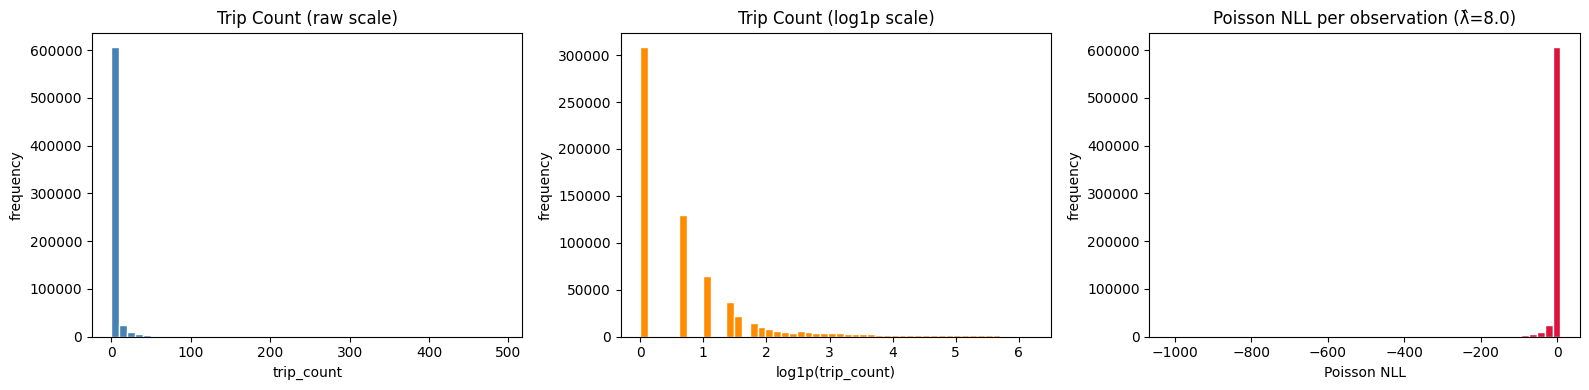

In [39]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (λ̂={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()

## 4.2.13 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# One figure over the three tuned architectures:
#   left  — train / val / test loss under the training criterion (mean ± std over seeds)
#   right — test-set MAE on the raw trip-count scale (mean ± std over seeds)
# Test loss is computed here with the same criterion as training, so the three
# bars per architecture are directly comparable (the overfitting-check printout
# in evaluate_models uses MSE on log1p scale regardless of the training loss).

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


RuntimeError: model has no training history — re-run the tuned training cells (train_model records it now)

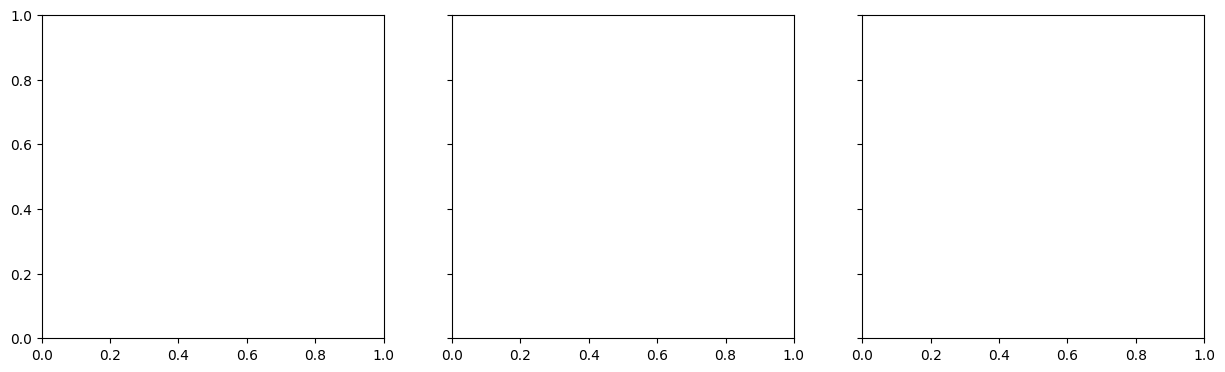

In [40]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Per-epoch train / val / test loss for the three tuned architectures.
# train_model records the history on each returned model; the tuned training
# cells pass test_data so the test curve is monitored per epoch too
# (monitoring only — it never influences training or model selection).

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


#### Interpreting the results

**What this tests.** For each tuned architecture the per-seed models are ensembled (mean predicted count) and scored on the held-out test set. For every test row we take the *absolute error* of the NN and of a benchmark and ask — across all rows jointly — whether the NN's errors are reliably smaller. Because every model predicts the **same** rows, the errors are *paired*.

**How the Wilcoxon signed-rank test works.** Each test row contributes one difference `d = AE_NN − AE_benchmark`. Rows with `d = 0` (ties) are dropped (that is the `n (non-tied)` count); the rest are ranked by the size of `|d|`, and the ranks of the "NN better" rows are summed against the "benchmark better" rows. If the NN were no better, those two rank-sums would be about equal — a large imbalance yields a small p-value. The test uses only the **signs and ranks** of the differences, so it is robust to the zero-inflated, heavy-tailed error distribution (unlike a paired t-test). It produces **one p-value per comparison**, computed from all rows together — p-values are never averaged.

**Reading the table.** Each row is one comparison (a tuned architecture vs. one benchmark):

| Column | Meaning |
|---|---|
| `median AE (NN)` / `median AE (bench)` | Typical absolute error of each model, in trips. |
| `median AE reduction` | `median AE (bench) − median AE (NN)`. **Positive → the NN is more accurate** by that many trips at the median; negative → the benchmark is. |
| `NN wins %` | Share of test rows where the NN's error is strictly smaller. ~50 % ≈ coin flip; higher = a consistent edge. |
| `W` | The signed-rank statistic the p-value is derived from (not read directly). |
| `p (one-sided)` | Raw probability of an NN advantage this strong if the NN were truly not better. |
| `n (non-tied)` | Number of rows that actually counted (ties dropped). |
| `p (Holm)` | The p-value **after** correcting for running six comparisons — the one to judge on. |
| `significant` | `True` when `p (Holm) < 0.05`. |

**Identifying significance.** A comparison is statistically significant when **`p (Holm) < 0.05`** — exactly what the `significant` column reports. Use the Holm-corrected value, not the raw `p (one-sided)`: six comparisons run at once, and Holm correction keeps the *overall* false-positive rate at 5 %. Because the test is one-sided, a significant row means specifically that the NN is **more accurate** than the benchmark, not merely different.

**Significance is not importance.** With thousands of paired rows, almost any difference clears `p < 0.05`, so always read significance together with the effect sizes. A significant row with a `median AE reduction` of 0.05 trips and `NN wins %` of 51 % is a statistical tie in practice; a reduction of ~3 trips with 68 % wins is a real improvement. And if a row is *not* significant, check the sign of `median AE reduction`: negative (with `NN wins %` < 50 %) means the benchmark is actually the better model.